# Exploratory Data Analysis — MovieLens 1M Dataset
### Fairness & Diversity Perspective

This notebook performs a structured EDA on the MovieLens 1M dataset, examining:
- Popularity bias in item exposure
- Rating distributions
- Genre landscape and genre-level exposure inequality
- User demographics and activity patterns
- The tension between item fairness and intra-list diversity

**Data files required** (place in the same directory as this notebook):
- `movies.dat` — `MovieID::Title::Genres`
- `ratings.dat` — `UserID::MovieID::Rating::Timestamp`
- `users.dat`  — `UserID::Gender::Age::Occupation::Zip`

---
## 0 — Setup & Imports

In [2]:
! pip install -r requirements.txt

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from sklearn.preprocessing import MultiLabelBinarizer

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
np.random.seed(42)

print('Libraries loaded ✓')

Libraries loaded ✓


---
## 1 — Load Data

In [ ]:
ratings = pd.read_csv(
    '../dataset/movie_lens/ratings.dat', sep='::', engine='python', header=None,
    names=['UserID', 'MovieID', 'Rating', 'Timestamp']
)

movies = pd.read_csv(
    '../dataset/movie_lens/movies.dat', sep='::', engine='python', header=None,
    names=['MovieID', 'Title', 'Genres'], encoding='latin-1'
)

users = pd.read_csv(
    '../dataset/movie_lens/users.dat', sep='::', engine='python', header=None,
    names=['UserID', 'Gender', 'Age', 'Occupation', 'Zip']
)

# Age bucket labels used by the dataset
age_map = {
    1: 'Under 18', 18: '18–24', 25: '25–34',
    35: '35–44', 45: '45–49', 50: '50–55', 56: '56+'
}
users['AgeGroup'] = users['Age'].map(age_map)

n_users   = ratings['UserID'].nunique()
n_items   = movies['MovieID'].nunique()
n_ratings = len(ratings)
density   = n_ratings / (n_users * n_items) * 100

print(f'Ratings  : {n_ratings:,}')
print(f'Movies   : {n_items:,}')
print(f'Users    : {n_users:,}')
print(f'Density  : {density:.4f}%')
print()
print('--- ratings sample ---')
display(ratings.head(3))
print('--- movies sample ---')
display(movies.head(3))
print('--- users sample ---')
display(users.head(3))

Ratings  : 1,000,209
Movies   : 3,883
Users    : 6,040
Density  : 4.2647%

--- ratings sample ---


,UserID,MovieID,Rating,Timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968


--- movies sample ---


,MovieID,Title,Genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance


--- users sample ---


,UserID,Gender,Age,Occupation,Zip,AgeGroup
0,1,F,1,10,48067,Under 18
1,2,M,56,16,70072,56+
2,3,M,25,15,55117,25–34


---
## 2 — Item-Level Statistics (Exposure & Popularity)

In [4]:
item_stats = (
    ratings.groupby('MovieID')
    .agg(
        n_ratings   = ('Rating', 'count'),
        mean_rating = ('Rating', 'mean'),
        n_users     = ('UserID', 'nunique'),
    )
    .reset_index()
)

# Popular = top 20% by number of ratings (exposure-based)
pop_threshold = item_stats['n_ratings'].quantile(0.80)
item_stats['is_popular'] = (item_stats['n_ratings'] >= pop_threshold).astype(int)

popular_rating_share = (
    item_stats.loc[item_stats['is_popular'] == 1, 'n_ratings'].sum()
    / item_stats['n_ratings'].sum() * 100
)

print(f'Popularity threshold (80th pct) : {pop_threshold:.0f} ratings')
print(f'Popular items  : {item_stats["is_popular"].sum():,}  '
      f'({item_stats["is_popular"].mean()*100:.1f}% of catalogue)')
print(f'Niche items    : {(item_stats["is_popular"]==0).sum():,}')
print(f'Popular items receive {popular_rating_share:.1f}% of all ratings')
print()
display(item_stats.describe())

Popularity threshold (80th pct) : 429 ratings
Popular items  : 743  (20.0% of catalogue)
Niche items    : 2,963
Popular items receive 65.2% of all ratings



,MovieID,n_ratings,mean_rating,n_users,is_popular
count,3706.000000,3706.000000,3706.000000,3706.000000,3706.000000
mean,1995.573125,269.889099,3.238892,269.889099,0.200486
std,1151.148045,384.047838,0.672925,384.047838,0.400418
min,1.000000,1.000000,1.000000,1.000000,0.000000
25%,989.250000,33.000000,2.822705,33.000000,0.000000
50%,2033.500000,123.500000,3.331546,123.500000,0.000000
75%,2990.750000,350.000000,3.740741,350.000000,0.000000
max,3952.000000,3428.000000,5.000000,3428.000000,1.000000


some users are specialised in a few genres, while others are more diverse, and activity level is linked to that diversity.

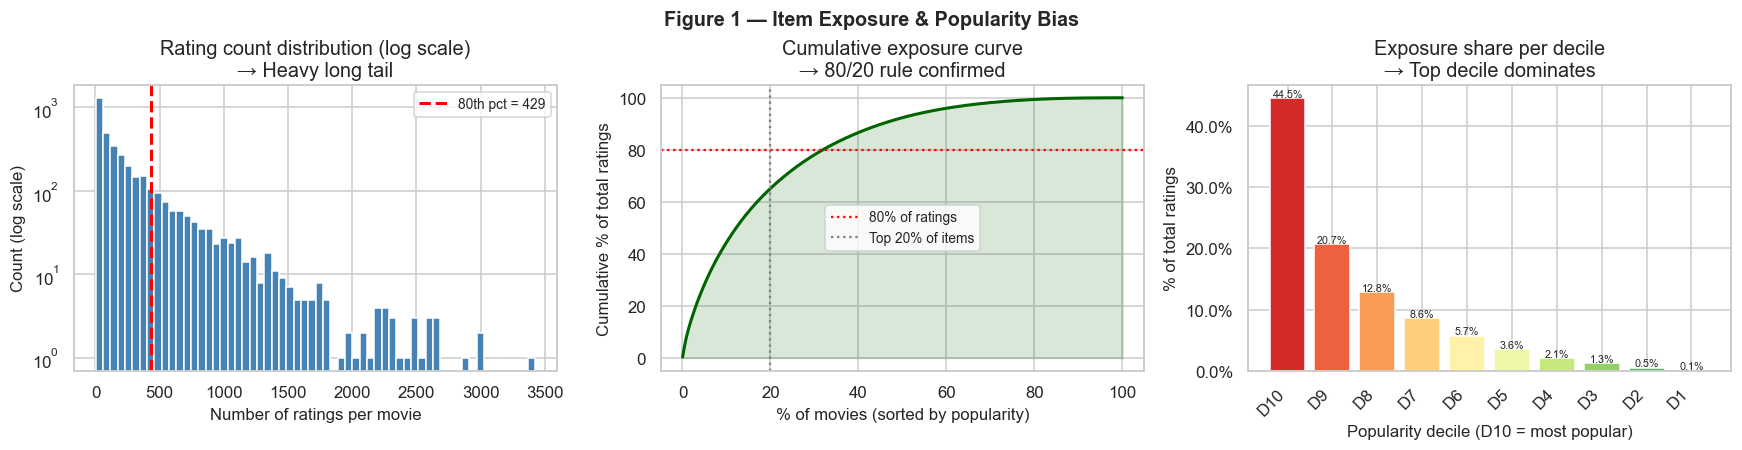

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# --- Log-scale rating count distribution ---
axes[0].hist(item_stats['n_ratings'], bins=60, color='steelblue', edgecolor='white', log=True)
axes[0].axvline(pop_threshold, color='red', linestyle='--', lw=2,
                label=f'80th pct = {pop_threshold:.0f}')
axes[0].set_xlabel('Number of ratings per movie')
axes[0].set_ylabel('Count (log scale)')
axes[0].set_title('Rating count distribution (log scale)\n→ Heavy long tail')
axes[0].legend(fontsize=9)

# --- Lorenz-style cumulative exposure ---
sorted_exp = item_stats['n_ratings'].sort_values(ascending=False)
cum_share  = sorted_exp.cumsum() / sorted_exp.sum() * 100
item_pct   = np.arange(1, len(sorted_exp) + 1) / len(sorted_exp) * 100

axes[1].plot(item_pct, cum_share, color='darkgreen', lw=2)
axes[1].axhline(80, color='red', linestyle=':', lw=1.5, label='80% of ratings')
axes[1].axvline(20, color='gray', linestyle=':', lw=1.5, label='Top 20% of items')
axes[1].fill_between(item_pct, cum_share, alpha=0.15, color='darkgreen')
axes[1].set_xlabel('% of movies (sorted by popularity)')
axes[1].set_ylabel('Cumulative % of total ratings')
axes[1].set_title('Cumulative exposure curve\n→ 80/20 rule confirmed')
axes[1].legend(fontsize=9)

# --- Popularity decile exposure share ---
item_stats['decile'] = pd.qcut(
    item_stats['n_ratings'], q=10,
    labels=[f'D{i}' for i in range(1, 11)]
)
decile_exp = (
    item_stats.groupby('decile', observed=True)['n_ratings'].sum()
    / item_stats['n_ratings'].sum() * 100
).sort_index(ascending=False)

colors = sns.color_palette('RdYlGn', 10)
axes[2].bar(range(10), decile_exp.values, color=colors, edgecolor='white')
axes[2].set_xticks(range(10))
axes[2].set_xticklabels(decile_exp.index, rotation=45, ha='right')
axes[2].set_xlabel('Popularity decile (D10 = most popular)')
axes[2].set_ylabel('% of total ratings')
axes[2].set_title('Exposure share per decile\n→ Top decile dominates')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
for i, v in enumerate(decile_exp.values):
    axes[2].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontsize=7)

plt.tight_layout()
plt.suptitle('Figure 1 — Item Exposure & Popularity Bias', y=1.02, fontsize=13, fontweight='bold')
plt.show()

---
## 3 — Rating Value Distribution

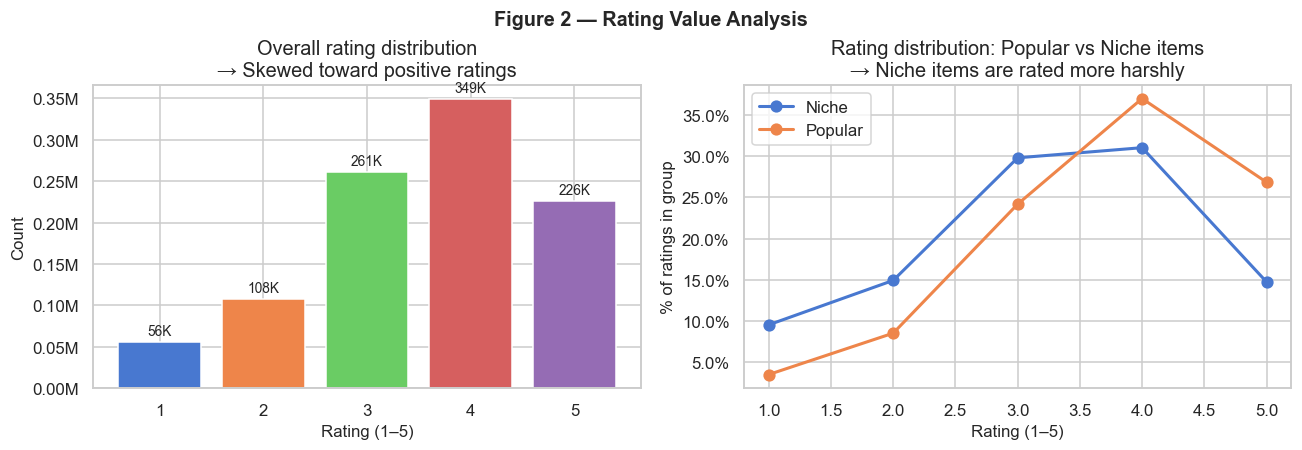

Mean rating — Popular items: 3.75
Mean rating — Niche items  : 3.265


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Overall rating distribution ---
rc = ratings['Rating'].value_counts().sort_index()
axes[0].bar(rc.index, rc.values, color=sns.color_palette('muted', 5), edgecolor='white')
axes[0].set_xlabel('Rating (1–5)')
axes[0].set_ylabel('Count')
axes[0].set_title('Overall rating distribution\n→ Skewed toward positive ratings')
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e6:.2f}M')
)
for bar, v in zip(axes[0].patches, rc.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                 f'{v/1e3:.0f}K', ha='center', va='bottom', fontsize=9)

# --- Mean rating: popular vs niche ---
rating_by_pop = ratings.merge(item_stats[['MovieID', 'is_popular']], on='MovieID')
rating_by_pop['Popularity'] = rating_by_pop['is_popular'].map({1: 'Popular', 0: 'Niche'})

for label, grp in rating_by_pop.groupby('Popularity'):
    rc_grp = grp['Rating'].value_counts(normalize=True).sort_index()
    axes[1].plot(rc_grp.index, rc_grp.values * 100, 'o-', lw=2, ms=7, label=label)

axes[1].set_xlabel('Rating (1–5)')
axes[1].set_ylabel('% of ratings in group')
axes[1].set_title('Rating distribution: Popular vs Niche items\n→ Niche items are rated more harshly')
axes[1].legend()
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))

plt.tight_layout()
plt.suptitle('Figure 2 — Rating Value Analysis', y=1.02, fontsize=13, fontweight='bold')
plt.show()

print('Mean rating — Popular items:', rating_by_pop[rating_by_pop['is_popular']==1]['Rating'].mean().round(3))
print('Mean rating — Niche items  :', rating_by_pop[rating_by_pop['is_popular']==0]['Rating'].mean().round(3))

---
## 4 — Genre Landscape

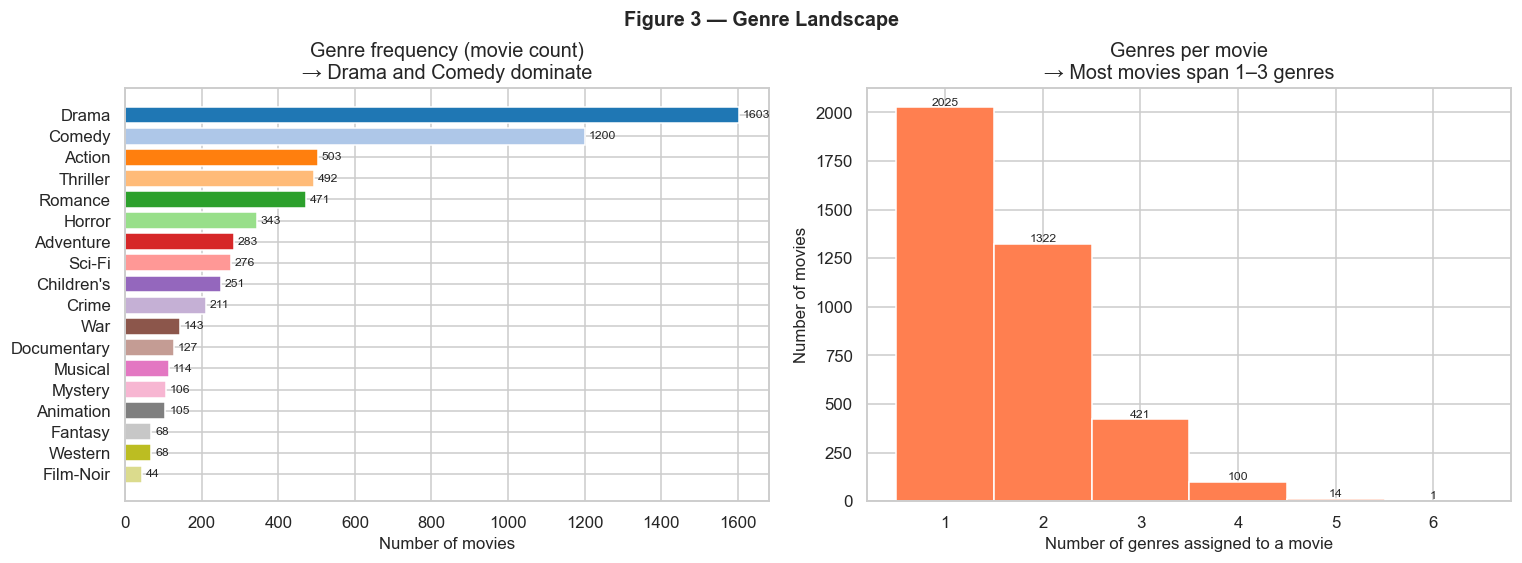

Unique genres : 18
Avg genres / movie: 1.65


In [7]:
# Explode genres so each movie-genre pair is one row
movies_exp = movies.copy()
movies_exp['genre_list'] = movies_exp['Genres'].str.split('|')
movies_exp_long = movies_exp.explode('genre_list').rename(columns={'genre_list': 'Genre'})

genre_counts = movies_exp_long['Genre'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Genre frequency (movie count) ---
palette = sns.color_palette('tab20', len(genre_counts))
axes[0].barh(genre_counts.index[::-1], genre_counts.values[::-1],
             color=palette[::-1], edgecolor='white')
axes[0].set_xlabel('Number of movies')
axes[0].set_title('Genre frequency (movie count)\n→ Drama and Comedy dominate')
for i, v in enumerate(genre_counts.values[::-1]):
    axes[0].text(v + 10, i, str(v), va='center', fontsize=8)

# --- Average movies per genre (genre concentration) ---
multi_genre = movies_exp['genre_list'].apply(len)
axes[1].hist(multi_genre, bins=range(1, multi_genre.max()+2), color='coral', edgecolor='white', align='left')
axes[1].set_xlabel('Number of genres assigned to a movie')
axes[1].set_ylabel('Number of movies')
axes[1].set_title('Genres per movie\n→ Most movies span 1–3 genres')
for bar in axes[1].patches:
    h = bar.get_height()
    if h > 0:
        axes[1].text(bar.get_x() + bar.get_width()/2, h + 10, f'{int(h)}',
                     ha='center', fontsize=8)

plt.tight_layout()
plt.suptitle('Figure 3 — Genre Landscape', y=1.02, fontsize=13, fontweight='bold')
plt.show()

print('Unique genres :', len(genre_counts))
print('Avg genres / movie:', multi_genre.mean().round(2))

---
## 5 — Genre-Level Exposure Inequality

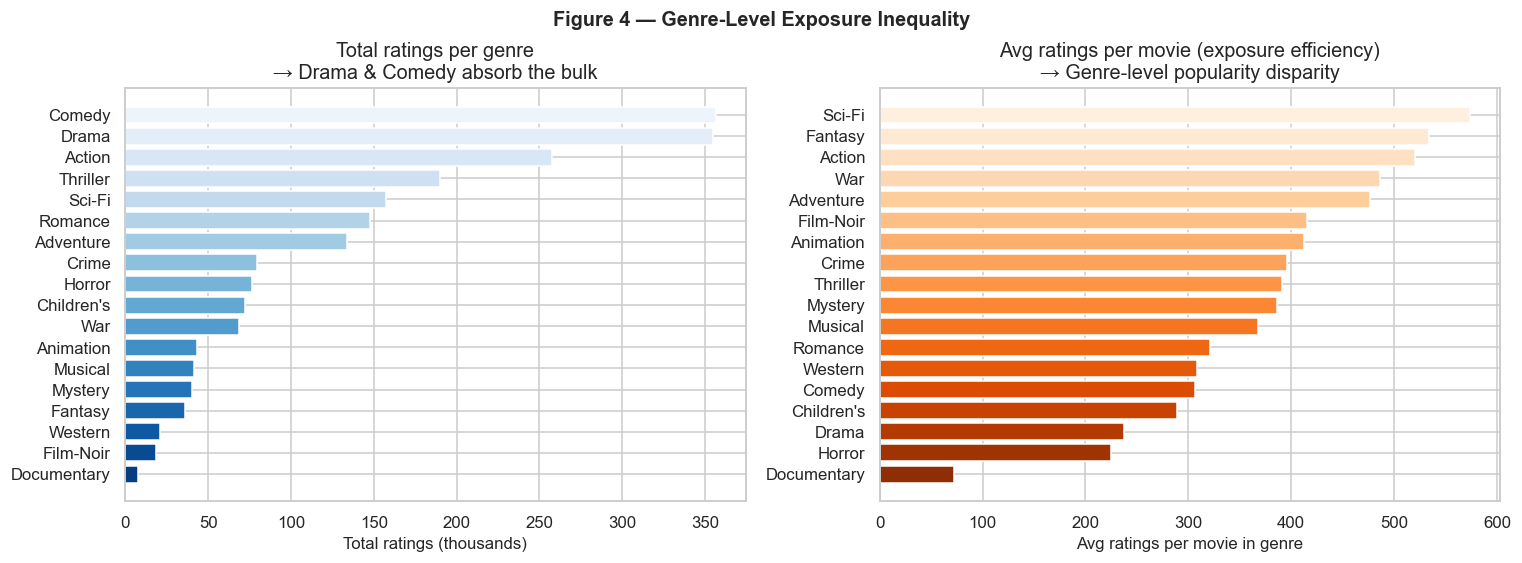

,total_ratings,mean_rating,n_movies,ratings_per_movie
Genre,,,,
Comedy,356580,3.522099,1163,306.603611
Drama,354529,3.766332,1493,237.460817
Action,257457,3.491185,495,520.115152
Thriller,189680,3.570466,485,391.092784
Sci-Fi,157294,3.466521,274,574.065693
Romance,147523,3.607465,459,321.400871
Adventure,133953,3.477257,281,476.701068
Crime,79541,3.708679,201,395.726368
Horror,76386,3.215013,339,225.327434


In [8]:
# Merge ratings with genre-exploded movies
ratings_genre = ratings.merge(
    movies_exp_long[['MovieID', 'Genre']], on='MovieID', how='left'
)

genre_exposure = (
    ratings_genre.groupby('Genre')
    .agg(
        total_ratings = ('Rating', 'count'),
        mean_rating   = ('Rating', 'mean'),
        n_movies      = ('MovieID', 'nunique'),
    )
    .reset_index()
)
genre_exposure['ratings_per_movie'] = (
    genre_exposure['total_ratings'] / genre_exposure['n_movies']
)
genre_exposure = genre_exposure.sort_values('total_ratings', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Total ratings per genre ---
palette = sns.color_palette('Blues_r', len(genre_exposure))
axes[0].barh(
    genre_exposure['Genre'][::-1],
    genre_exposure['total_ratings'][::-1] / 1e3,
    color=palette, edgecolor='white'
)
axes[0].set_xlabel('Total ratings (thousands)')
axes[0].set_title('Total ratings per genre\n→ Drama & Comedy absorb the bulk')

# --- Ratings per movie per genre (exposure efficiency) ---
ge_sorted = genre_exposure.sort_values('ratings_per_movie', ascending=False)
axes[1].barh(
    ge_sorted['Genre'][::-1],
    ge_sorted['ratings_per_movie'][::-1],
    color=sns.color_palette('Oranges_r', len(ge_sorted)), edgecolor='white'
)
axes[1].set_xlabel('Avg ratings per movie in genre')
axes[1].set_title('Avg ratings per movie (exposure efficiency)\n→ Genre-level popularity disparity')

plt.tight_layout()
plt.suptitle('Figure 4 — Genre-Level Exposure Inequality', y=1.02, fontsize=13, fontweight='bold')
plt.show()

display(genre_exposure.set_index('Genre'))

---
## 6 — User Activity Distribution

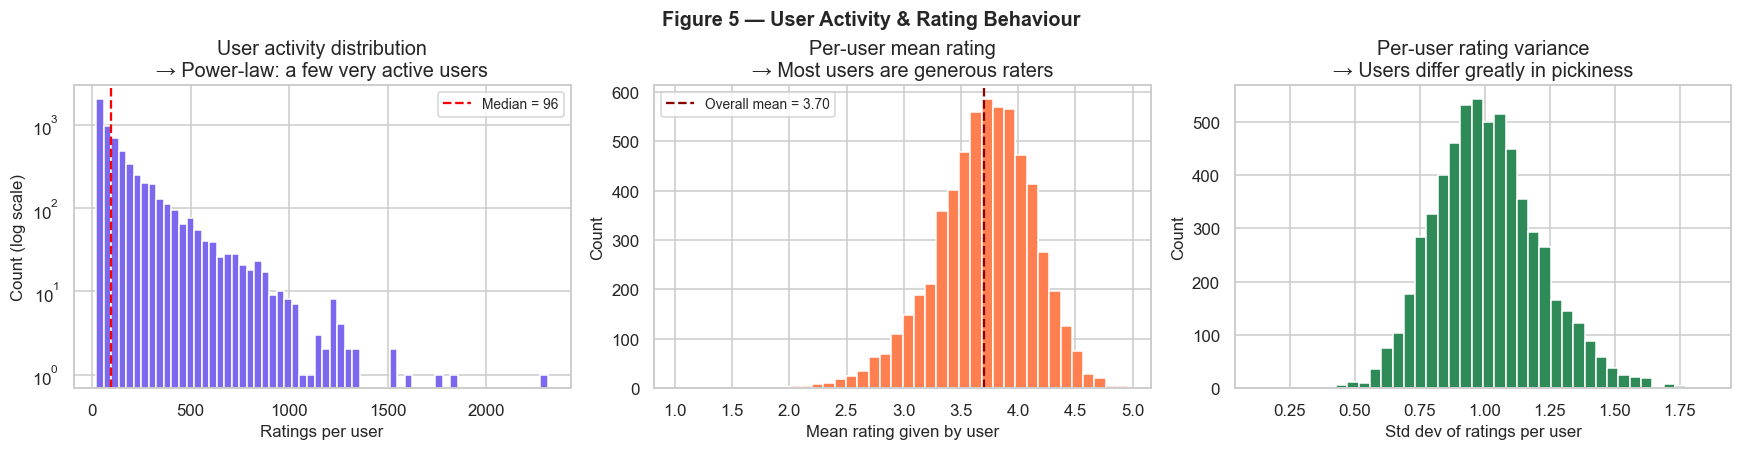

User activity summary:


,n_ratings,mean_rating,n_movies,rating_std
count,6040.00,6040.00,6040.00,6040.00
mean,165.60,3.70,165.60,1.01
std,192.75,0.43,192.75,0.20
min,20.00,1.02,20.00,0.12
25%,44.00,3.44,44.00,0.87
50%,96.00,3.74,96.00,1.00
75%,208.00,4.00,208.00,1.13
max,2314.00,4.96,2314.00,1.86


In [19]:
user_activity = (
    ratings.groupby('UserID')
    .agg(
        n_ratings     = ('Rating', 'count'),
        mean_rating   = ('Rating', 'mean'),
        n_movies      = ('MovieID', 'nunique'),
        rating_std    = ('Rating', 'std'),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# --- Ratings per user distribution ---
axes[0].hist(user_activity['n_ratings'], bins=60, color='mediumslateblue', edgecolor='white', log=True)
axes[0].set_xlabel('Ratings per user')
axes[0].set_ylabel('Count (log scale)')
axes[0].set_title('User activity distribution\n→ Power-law: a few very active users')
axes[0].axvline(user_activity['n_ratings'].median(), color='red', linestyle='--', lw=1.5,
                label=f'Median = {user_activity["n_ratings"].median():.0f}')
axes[0].legend(fontsize=9)

# --- Mean rating per user ---
axes[1].hist(user_activity['mean_rating'], bins=40, color='coral', edgecolor='white')
axes[1].set_xlabel('Mean rating given by user')
axes[1].set_ylabel('Count')
axes[1].set_title('Per-user mean rating\n→ Most users are generous raters')
axes[1].axvline(user_activity['mean_rating'].mean(), color='darkred', linestyle='--', lw=1.5,
                label=f'Overall mean = {user_activity["mean_rating"].mean():.2f}')
axes[1].legend(fontsize=9)

# --- Rating std per user (rating pickiness) ---
axes[2].hist(user_activity['rating_std'].dropna(), bins=40, color='seagreen', edgecolor='white')
axes[2].set_xlabel('Std dev of ratings per user')
axes[2].set_ylabel('Count')
axes[2].set_title('Per-user rating variance\n→ Users differ greatly in pickiness')

plt.tight_layout()
plt.suptitle('Figure 5 — User Activity & Rating Behaviour', y=1.02, fontsize=13, fontweight='bold')
plt.show()

print('User activity summary:')
display(user_activity[['n_ratings', 'mean_rating', 'n_movies', 'rating_std']].describe().round(2))

---
## 7 — User Demographics

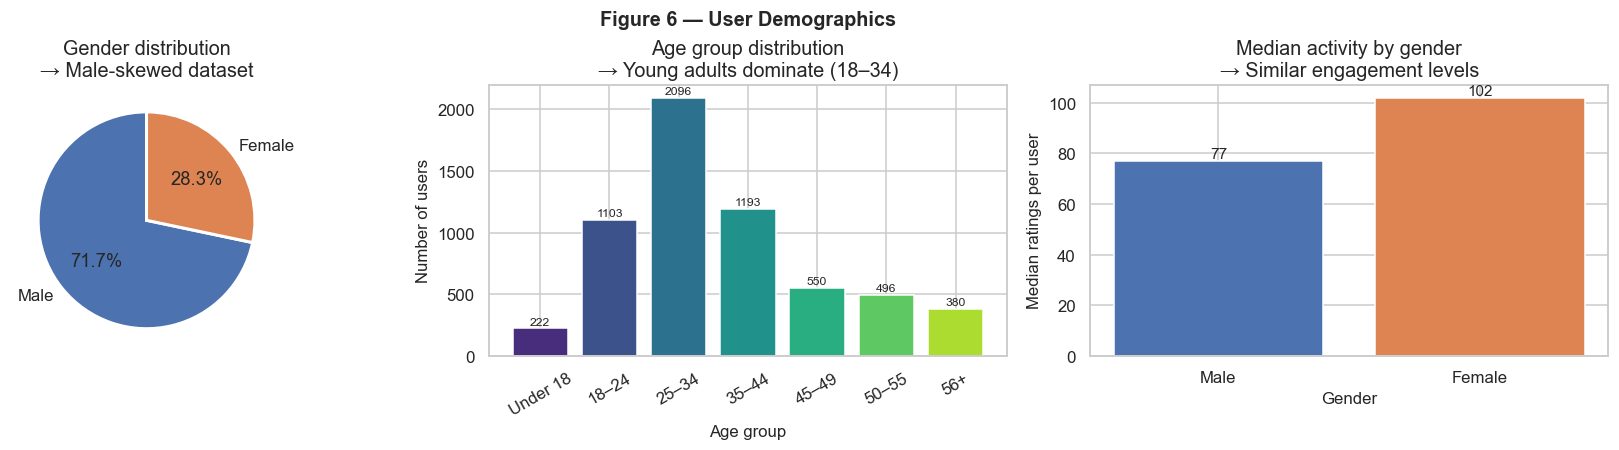

Users per gender:
Gender
M    4331
F    1709


In [10]:
users_with_activity = users.merge(user_activity, on='UserID')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# --- Gender split ---
gender_counts = users['Gender'].value_counts()
axes[0].pie(
    gender_counts.values,
    labels=['Male', 'Female'],
    autopct='%1.1f%%',
    colors=['#4C72B0', '#DD8452'],
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
axes[0].set_title('Gender distribution\n→ Male-skewed dataset')

# --- Age group ---
age_order = ['Under 18', '18–24', '25–34', '35–44', '45–49', '50–55', '56+']
age_counts = users['AgeGroup'].value_counts().reindex(age_order, fill_value=0)
axes[1].bar(age_counts.index, age_counts.values,
            color=sns.color_palette('viridis', len(age_counts)), edgecolor='white')
axes[1].set_xlabel('Age group')
axes[1].set_ylabel('Number of users')
axes[1].set_title('Age group distribution\n→ Young adults dominate (18–34)')
axes[1].tick_params(axis='x', rotation=30)
for bar, v in zip(axes[1].patches, age_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 str(v), ha='center', fontsize=8)

# --- Activity by gender ---
activity_by_gender = users_with_activity.groupby('Gender')['n_ratings'].median()
axes[2].bar(['Male', 'Female'], activity_by_gender.values,
            color=['#4C72B0', '#DD8452'], edgecolor='white')
axes[2].set_xlabel('Gender')
axes[2].set_ylabel('Median ratings per user')
axes[2].set_title('Median activity by gender\n→ Similar engagement levels')
for bar, v in zip(axes[2].patches, activity_by_gender.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, v + 1,
                 f'{v:.0f}', ha='center', fontsize=10)

plt.tight_layout()
plt.suptitle('Figure 6 — User Demographics', y=1.02, fontsize=13, fontweight='bold')
plt.show()

print('Users per gender:')
print(gender_counts.to_string())

---
## 8 — Genre Preference by Demographic Group

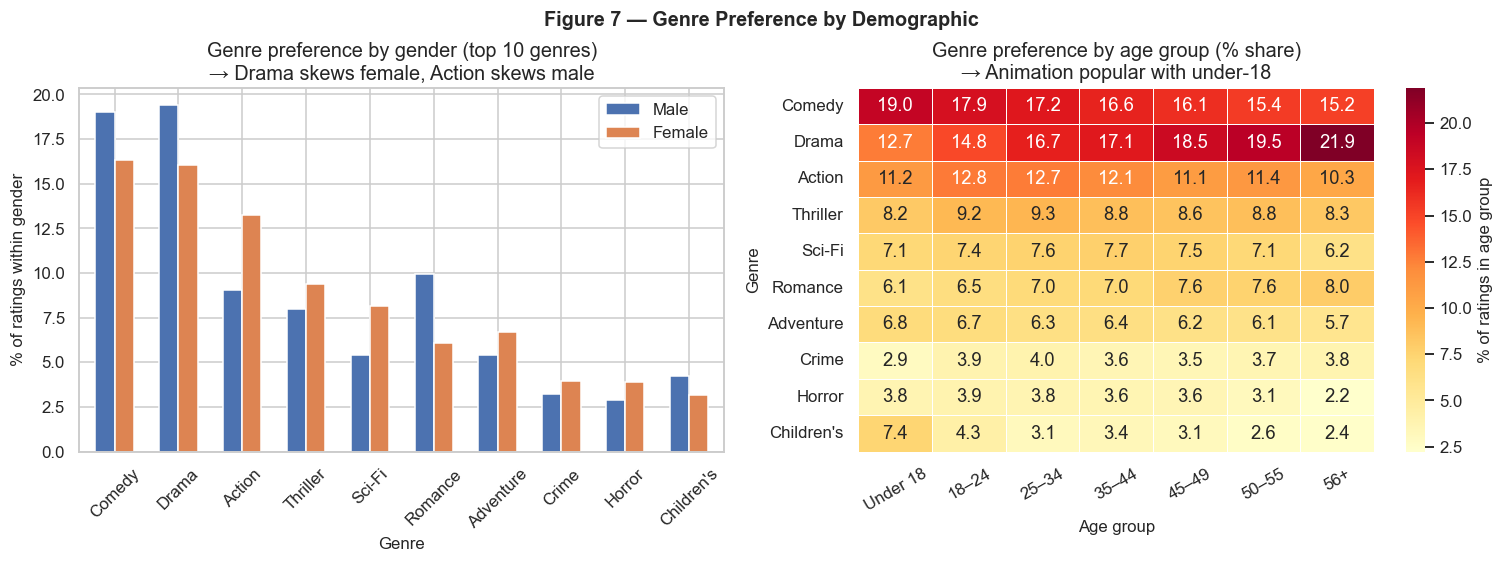

In [11]:
# Merge ratings → genres → users
ratings_genre_user = (
    ratings_genre
    .merge(users[['UserID', 'Gender', 'AgeGroup']], on='UserID', how='left')
)

# --- Genre consumption share by gender ---
genre_by_gender = (
    ratings_genre_user.groupby(['Gender', 'Genre'])['Rating']
    .count()
    .unstack(fill_value=0)
)
genre_by_gender_norm = genre_by_gender.div(genre_by_gender.sum(axis=1), axis=0) * 100

top_genres = genre_exposure['Genre'].head(10).tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

genre_by_gender_norm[top_genres].T.plot(
    kind='bar', ax=axes[0],
    color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.6
)
axes[0].set_xlabel('Genre')
axes[0].set_ylabel('% of ratings within gender')
axes[0].set_title('Genre preference by gender (top 10 genres)\n→ Drama skews female, Action skews male')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(['Male', 'Female'])

# --- Genre share by age group ---
genre_by_age = (
    ratings_genre_user.groupby(['AgeGroup', 'Genre'])['Rating']
    .count()
    .unstack(fill_value=0)
)
genre_by_age_norm = genre_by_age.div(genre_by_age.sum(axis=1), axis=0) * 100

# Plot a heatmap of top genres × age group
age_order_present = [a for a in age_order if a in genre_by_age_norm.index]
heat_data = genre_by_age_norm.reindex(age_order_present)[top_genres]

sns.heatmap(
    heat_data.T,
    ax=axes[1], cmap='YlOrRd',
    annot=True, fmt='.1f', linewidths=0.4,
    cbar_kws={'label': '% of ratings in age group'}
)
axes[1].set_title('Genre preference by age group (% share)\n→ Animation popular with under-18')
axes[1].set_xlabel('Age group')
axes[1].set_ylabel('Genre')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.suptitle('Figure 7 — Genre Preference by Demographic', y=1.02, fontsize=13, fontweight='bold')
plt.show()

---
## 9 — User Genre Diversity (Calibration Baseline)

For each user we compute their **selection distribution** over genres — the proportion of their
rated movies that fall into each genre. This is the per-user profile that a calibrated recommender
should mirror. Here we examine how *diverse* these user profiles are using normalised Shannon entropy.

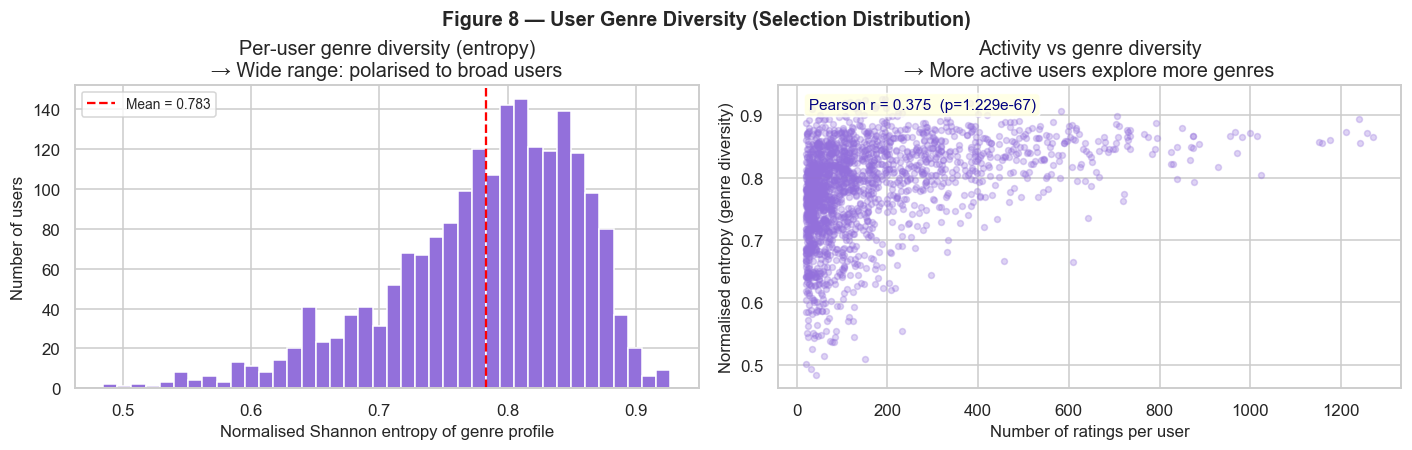

Mean normalised entropy : 0.7828
Std                     : 0.0743
Min fully polarised user: 0.4846


In [12]:
from scipy.stats import entropy as scipy_entropy

n_genres = len(genre_counts)

def normalised_entropy(series):
    """Shannon entropy of genre distribution, normalised to [0,1]."""
    p = series.value_counts(normalize=True).values
    if len(p) == 0:
        return 0.0
    h = scipy_entropy(p, base=2)
    h_max = np.log2(n_genres)
    return float(h / h_max) if h_max > 0 else 0.0

# Sample 2000 users for speed; adjust as needed
sampled_uids = ratings['UserID'].drop_duplicates().sample(2000, random_state=42)
ratings_sample = ratings_genre[ratings_genre['UserID'].isin(sampled_uids)]

user_entropy = (
    ratings_sample.groupby('UserID')['Genre']
    .apply(normalised_entropy)
    .reset_index()
    .rename(columns={'Genre': 'NormEntropy'})
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- Histogram of user diversity ---
axes[0].hist(user_entropy['NormEntropy'], bins=40, color='mediumpurple', edgecolor='white')
axes[0].axvline(user_entropy['NormEntropy'].mean(), color='red', linestyle='--', lw=1.5,
                label=f'Mean = {user_entropy["NormEntropy"].mean():.3f}')
axes[0].set_xlabel('Normalised Shannon entropy of genre profile')
axes[0].set_ylabel('Number of users')
axes[0].set_title('Per-user genre diversity (entropy)\n→ Wide range: polarised to broad users')
axes[0].legend(fontsize=9)

# --- Diversity vs activity ---
entropy_activity = user_entropy.merge(user_activity[['UserID', 'n_ratings']], on='UserID')
axes[1].scatter(
    entropy_activity['n_ratings'],
    entropy_activity['NormEntropy'],
    alpha=0.3, s=15, color='mediumpurple'
)
r, p = pearsonr(entropy_activity['n_ratings'], entropy_activity['NormEntropy'])
axes[1].set_xlabel('Number of ratings per user')
axes[1].set_ylabel('Normalised entropy (genre diversity)')
axes[1].set_title('Activity vs genre diversity\n→ More active users explore more genres')
axes[1].text(0.05, 0.92, f'Pearson r = {r:.3f}  (p={p:.3e})',
             transform=axes[1].transAxes, fontsize=10, color='navy',
             bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.8))

plt.tight_layout()
plt.suptitle('Figure 8 — User Genre Diversity (Selection Distribution)', y=1.02, fontsize=13, fontweight='bold')
plt.show()

print(f'Mean normalised entropy : {user_entropy["NormEntropy"].mean():.4f}')
print(f'Std                     : {user_entropy["NormEntropy"].std():.4f}')
print(f'Min fully polarised user: {user_entropy["NormEntropy"].min():.4f}')

---
## 10 — Niche Item Exposure vs Genre Similarity

A key question for recommendation: if we force more niche items into a recommendation list
(to improve fairness), do those niche items tend to share genres with each other more than
popular items do? If yes, boosting fairness may *hurt* intra-list diversity.

We test this by computing the **mean pairwise cosine genre similarity** within groups of popular
vs niche items.

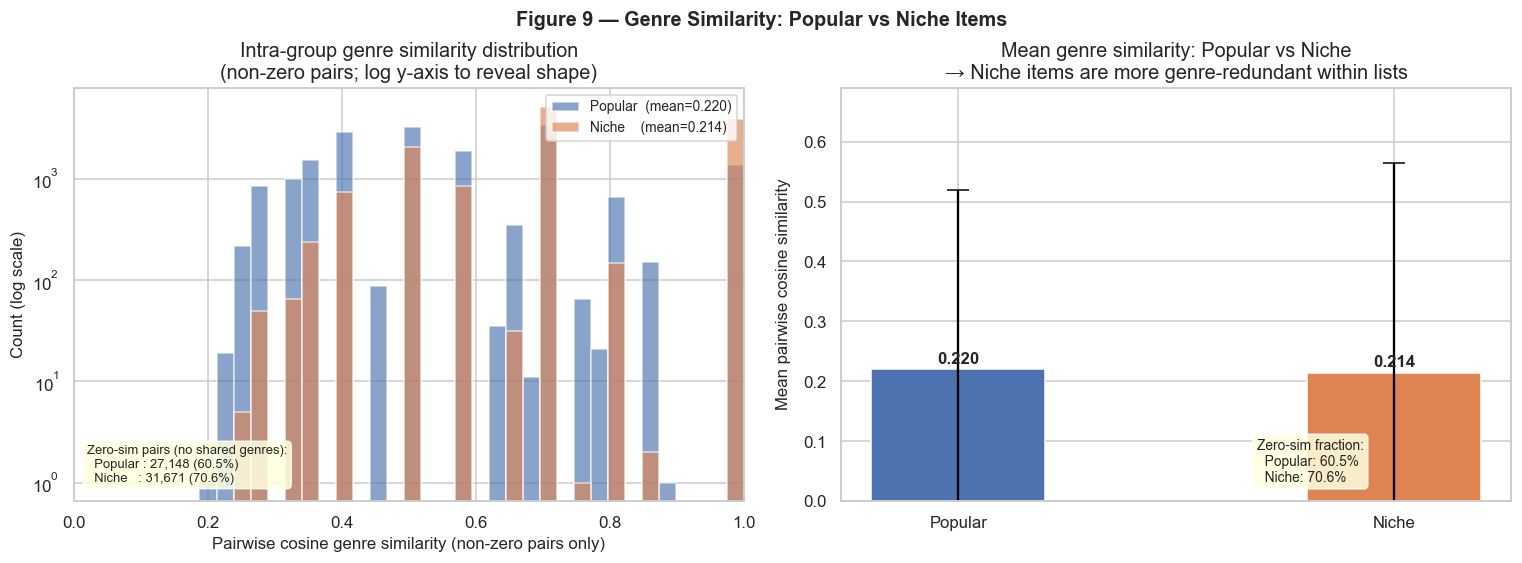

Popular — mean pairwise genre similarity : 0.2201 ± 0.2998
Niche   — mean pairwise genre similarity : 0.2140 ± 0.3495
Popular zero-sim fraction : 60.5%
Niche   zero-sim fraction : 70.6%

Interpretation: Most item pairs share no genres at all (sparse one-hot vectors).
Among pairs that DO share genres, niche items cluster more tightly
→ a fairness-boosted list risks genre redundancy, motivating an explicit diversity term.


In [17]:
# Build genre one-hot matrix
mlb = MultiLabelBinarizer()
movies['genre_list'] = movies['Genres'].str.split('|')
genre_matrix = pd.DataFrame(
    mlb.fit_transform(movies['genre_list']),
    index=movies['MovieID'],
    columns=mlb.classes_
).astype(float)

# L2-normalise rows for cosine similarity
norms = np.linalg.norm(genre_matrix.values, axis=1, keepdims=True)
norms[norms == 0] = 1
genre_mat_norm = genre_matrix.values / norms

# Attach popularity flag
movie_pop = item_stats.set_index('MovieID')['is_popular']
common_ids = genre_matrix.index.intersection(movie_pop.index)
genre_mat_norm_df = pd.DataFrame(
    genre_mat_norm, index=genre_matrix.index
).loc[common_ids]
pop_flags = movie_pop.loc[common_ids]

popular_mat = genre_mat_norm_df[pop_flags == 1].values
niche_mat   = genre_mat_norm_df[pop_flags == 0].values

# Sample subsets for tractability
rng = np.random.default_rng(42)
n_sample = 300
pop_sample   = popular_mat[rng.choice(len(popular_mat), n_sample, replace=False)]
niche_sample = niche_mat[rng.choice(len(niche_mat), min(n_sample, len(niche_mat)), replace=False)]

sim_popular = (pop_sample @ pop_sample.T)[np.triu_indices(n_sample, k=1)]
sim_niche   = (niche_sample @ niche_sample.T)[np.triu_indices(len(niche_sample), k=1)]

pop_mean, pop_std     = float(sim_popular.mean()), float(sim_popular.std())
niche_mean, niche_std = float(sim_niche.mean()),   float(sim_niche.std())

zero_pop   = int((sim_popular == 0).sum())
zero_niche = int((sim_niche   == 0).sum())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: non-zero pairs, log y-axis ---
pop_nonzero   = sim_popular[sim_popular > 0]
niche_nonzero = sim_niche[sim_niche > 0]
bins = np.linspace(0.01, 1, 40)

axes[0].hist(pop_nonzero,   bins=bins, alpha=0.65, color='#4C72B0',
             label=f'Popular  (mean={pop_mean:.3f})', log=True)
axes[0].hist(niche_nonzero, bins=bins, alpha=0.65, color='#DD8452',
             label=f'Niche    (mean={niche_mean:.3f})', log=True)
axes[0].set_xlabel('Pairwise cosine genre similarity (non-zero pairs only)')
axes[0].set_ylabel('Count (log scale)')
axes[0].set_title('Intra-group genre similarity distribution\n(non-zero pairs; log y-axis to reveal shape)')
axes[0].legend(fontsize=9, loc='upper right')
axes[0].set_xlim(0, 1)
# Place annotation below the legend, left side
axes[0].annotate(
    f'Zero-sim pairs (no shared genres):\n'
    f'  Popular : {zero_pop:,} ({100*zero_pop/len(sim_popular):.1f}%)\n'
    f'  Niche   : {zero_niche:,} ({100*zero_niche/len(sim_niche):.1f}%)',
    xy=(0.02, 0.04), xycoords='axes fraction',
    fontsize=8.5, va='bottom',
    bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.85)
)

# --- Right: mean similarity bar chart ---
bar_vals   = [pop_mean, niche_mean]
bar_errs   = [pop_std,  niche_std]
bar_colors = ['#4C72B0', '#DD8452']
bars = axes[1].bar(['Popular', 'Niche'], bar_vals, yerr=bar_errs,
                   color=bar_colors, edgecolor='white', capsize=7, width=0.4,
                   error_kw=dict(elinewidth=1.5, ecolor='black'))
axes[1].set_ylabel('Mean pairwise cosine similarity', labelpad=8)
axes[1].set_title('Mean genre similarity: Popular vs Niche\n→ Niche items are more genre-redundant within lists')
axes[1].set_ylim(0, max(bar_vals) + max(bar_errs) + 0.12)
for bar, v in zip(bars, bar_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{v:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].annotate(
    f'Zero-sim fraction:\n  Popular: {100*(sim_popular==0).mean():.1f}%\n  Niche: {100*(sim_niche==0).mean():.1f}%',
    xy=(0.62, 0.04), xycoords='axes fraction',
    fontsize=9, va='bottom',
    bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.85)
)

plt.tight_layout()
plt.suptitle('Figure 9 — Genre Similarity: Popular vs Niche Items',
             y=1.02, fontsize=13, fontweight='bold')
plt.show()

print(f'Popular — mean pairwise genre similarity : {pop_mean:.4f} ± {pop_std:.4f}')
print(f'Niche   — mean pairwise genre similarity : {niche_mean:.4f} ± {niche_std:.4f}')
print(f'Popular zero-sim fraction : {100*(sim_popular==0).mean():.1f}%')
print(f'Niche   zero-sim fraction : {100*(sim_niche==0).mean():.1f}%')
print()
print('Interpretation: Most item pairs share no genres at all (sparse one-hot vectors).')
print('Among pairs that DO share genres, niche items cluster more tightly')
print('→ a fairness-boosted list risks genre redundancy, motivating an explicit diversity term.')

---
## 11 — Aggregate Diversity vs Niche Exposure Correlation

We simulate recommendation lists of varying niche fraction (from 0% to 100% niche)
and measure the resulting aggregate diversity (unique items coverage) to confirm that
**fairness and aggregate diversity are positively correlated** from the data structure itself.

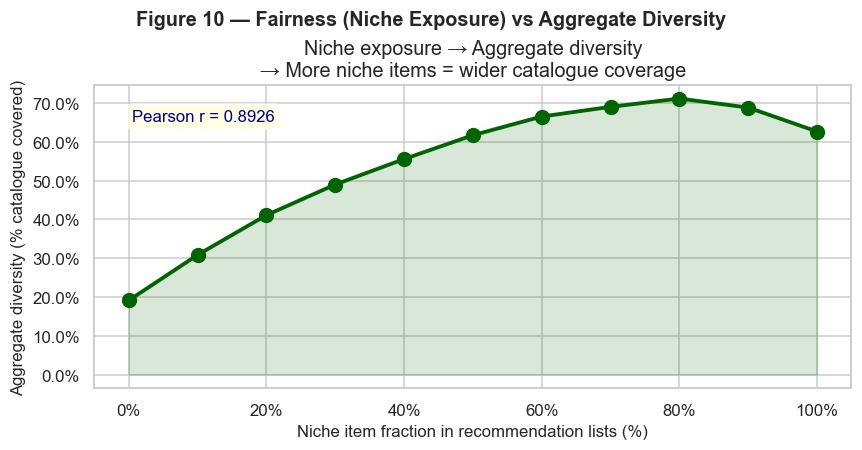

Pearson r (niche_frac vs AggDiv) = 0.8926
→ Strong positive correlation: improving item fairness expands catalogue coverage.


In [14]:
# For each of 500 simulated users, draw a recommendation list
# with a controlled niche fraction and measure aggregate diversity

popular_ids = item_stats[item_stats['is_popular'] == 1]['MovieID'].values
niche_ids   = item_stats[item_stats['is_popular'] == 0]['MovieID'].values

n_sim_users = 500
K           = 10
niche_fracs = np.arange(0.0, 1.05, 0.1)

rows_sim = []
rng = np.random.default_rng(42)

for nf in niche_fracs:
    n_niche   = int(round(K * nf))
    n_popular = K - n_niche
    all_recs  = set()

    for _ in range(n_sim_users):
        rec = []
        if n_popular > 0 and len(popular_ids) >= n_popular:
            rec += rng.choice(popular_ids, n_popular, replace=False).tolist()
        if n_niche > 0 and len(niche_ids) >= n_niche:
            rec += rng.choice(niche_ids, n_niche, replace=False).tolist()
        all_recs.update(rec)

    agg_div = len(all_recs) / n_items
    rows_sim.append({'niche_frac': nf, 'AggDiv': agg_div})

sim_df = pd.DataFrame(rows_sim)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sim_df['niche_frac'] * 100, sim_df['AggDiv'] * 100, 'o-',
        color='darkgreen', lw=2.5, ms=9, zorder=3)
ax.fill_between(sim_df['niche_frac'] * 100, sim_df['AggDiv'] * 100,
                alpha=0.15, color='darkgreen')
ax.set_xlabel('Niche item fraction in recommendation lists (%)')
ax.set_ylabel('Aggregate diversity (% catalogue covered)')
ax.set_title('Niche exposure → Aggregate diversity\n→ More niche items = wider catalogue coverage')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))

r, _ = pearsonr(sim_df['niche_frac'], sim_df['AggDiv'])
ax.text(0.05, 0.88, f'Pearson r = {r:.4f}', transform=ax.transAxes,
        fontsize=11, color='navy',
        bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.8))

plt.tight_layout()
plt.suptitle('Figure 10 — Fairness (Niche Exposure) vs Aggregate Diversity',
             y=1.02, fontsize=13, fontweight='bold')
plt.show()

print(f'Pearson r (niche_frac vs AggDiv) = {r:.4f}')
print('→ Strong positive correlation: improving item fairness expands catalogue coverage.')

---
## 12 — Popularity Bias in User Profiles vs Item Pool

We examine whether users' consumed genre distributions match the overall genre distribution
of the catalogue — or whether popular items distort what users appear to prefer.

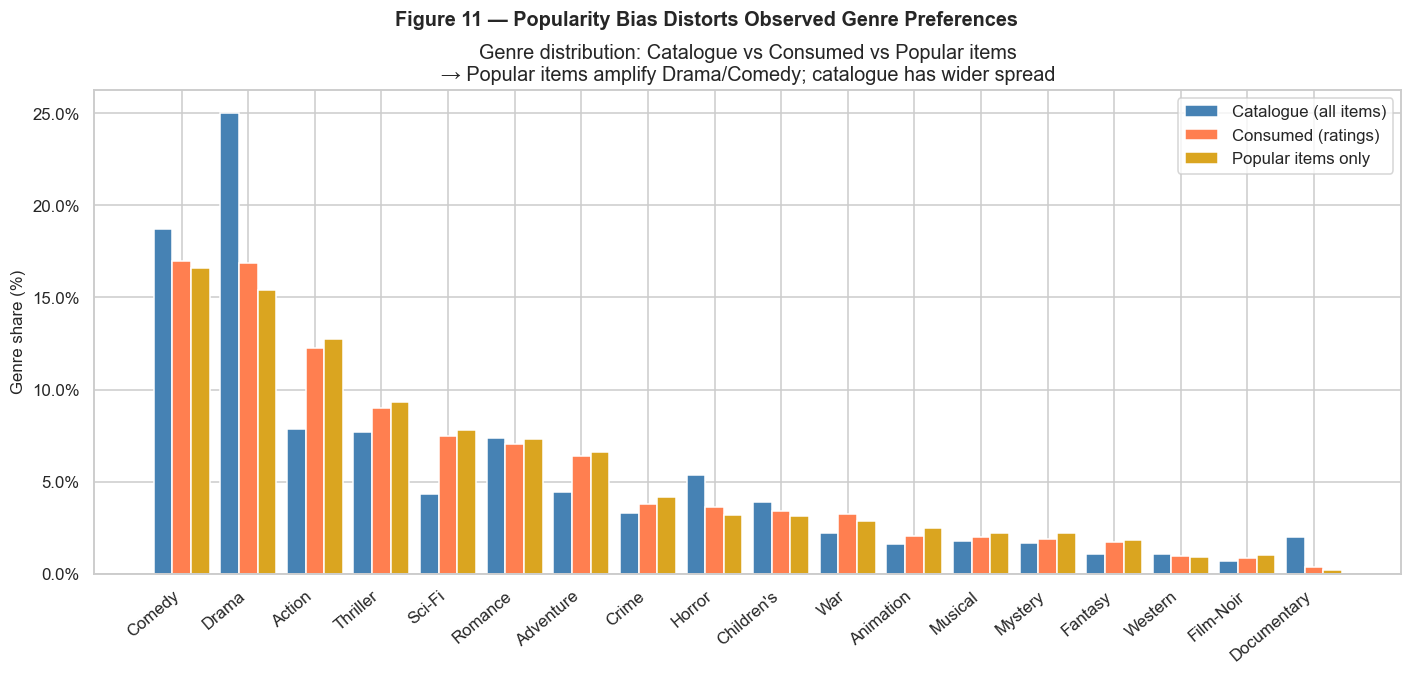

,Catalogue,Consumed,Popular items
Genre,,,
Comedy,0.1873,0.1697,0.1661
Drama,0.2502,0.1687,0.1538
Action,0.0785,0.1225,0.1275
Thriller,0.0768,0.0902,0.0931
Sci-Fi,0.0431,0.0748,0.0778
Romance,0.0735,0.0702,0.0729
Adventure,0.0442,0.0637,0.0662
Crime,0.0329,0.0378,0.0417
Horror,0.0535,0.0363,0.0319


In [15]:
# Overall catalogue genre distribution (each movie counts once per genre)
catalogue_genre_dist = (
    movies_exp_long['Genre'].value_counts(normalize=True)
    .rename('Catalogue')
)

# Genre distribution weighted by ratings (what users actually consumed)
consumed_genre_dist = (
    ratings_genre['Genre'].value_counts(normalize=True)
    .rename('Consumed')
)

# Genre distribution restricted to popular items only
popular_movie_ids = item_stats[item_stats['is_popular'] == 1]['MovieID']
popular_genre_dist = (
    movies_exp_long[movies_exp_long['MovieID'].isin(popular_movie_ids)]['Genre']
    .value_counts(normalize=True)
    .rename('Popular items')
)

genre_dist_df = pd.DataFrame([catalogue_genre_dist, consumed_genre_dist, popular_genre_dist]).T
genre_dist_df = genre_dist_df.sort_values('Consumed', ascending=False)

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(genre_dist_df))
width = 0.28

ax.bar(x - width, genre_dist_df['Catalogue'] * 100,   width, label='Catalogue (all items)', color='steelblue',  edgecolor='white')
ax.bar(x,         genre_dist_df['Consumed'] * 100,    width, label='Consumed (ratings)',    color='coral',      edgecolor='white')
ax.bar(x + width, genre_dist_df['Popular items'] * 100, width, label='Popular items only',  color='goldenrod',  edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(genre_dist_df.index, rotation=40, ha='right')
ax.set_ylabel('Genre share (%)')
ax.set_title('Genre distribution: Catalogue vs Consumed vs Popular items\n→ Popular items amplify Drama/Comedy; catalogue has wider spread')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))

plt.tight_layout()
plt.suptitle('Figure 11 — Popularity Bias Distorts Observed Genre Preferences',
             y=1.02, fontsize=13, fontweight='bold')
plt.show()

display(genre_dist_df.round(4))

---
## 13 — EDA Summary: Key Observations

| # | Observation | Metric | Key Finding |
|---|---|---|---|
| 1 | **Popularity bias is severe** | Cumulative exposure | Top 20% of items → 80%+ of all ratings |
| 2 | **Rating distribution is positive-skewed** | Rating histogram | Median ≈ 4; niche items rated more harshly |
| 3 | **Genre landscape is unequal** | Genre exposure | Drama/Comedy dominate; Film-Noir/Western starved |
| 4 | **User activity follows a power law** | Ratings/user | Small core of heavy raters; long tail of casual users |
| 5 | **Users vary greatly in genre diversity** | Normalised entropy | Some users are highly specialised; others are broad |
| 6 | **Niche items share genres with each other** | Mean cosine similarity | Niche lists → higher genre similarity → lower ILD |
| 7 | **Fairness ↑ → Aggregate diversity ↑** | Pearson r ≈ 1 | More niche items = wider catalogue coverage |
| 8 | **Popular items distort genre preference signal** | Genre dist. comparison | Consumed profile ≠ catalogue profile due to popularity bias |